#Exp-3.
Predicting Stock Prices:
Develop a time series prediction model to forecast stock prices.

Generated Stock Data Head:
                 Price
Date                  
2023-01-01  100.496714
2023-01-02  100.358450
2023-01-03  101.006138
2023-01-04  102.529168
2023-01-05  102.295015

ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                   80
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -107.275
Date:                Tue, 10 Feb 2026   AIC                            226.550
Time:                        04:03:18   BIC                            240.767
Sample:                    01-01-2023   HQIC                           232.246
                         - 03-21-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


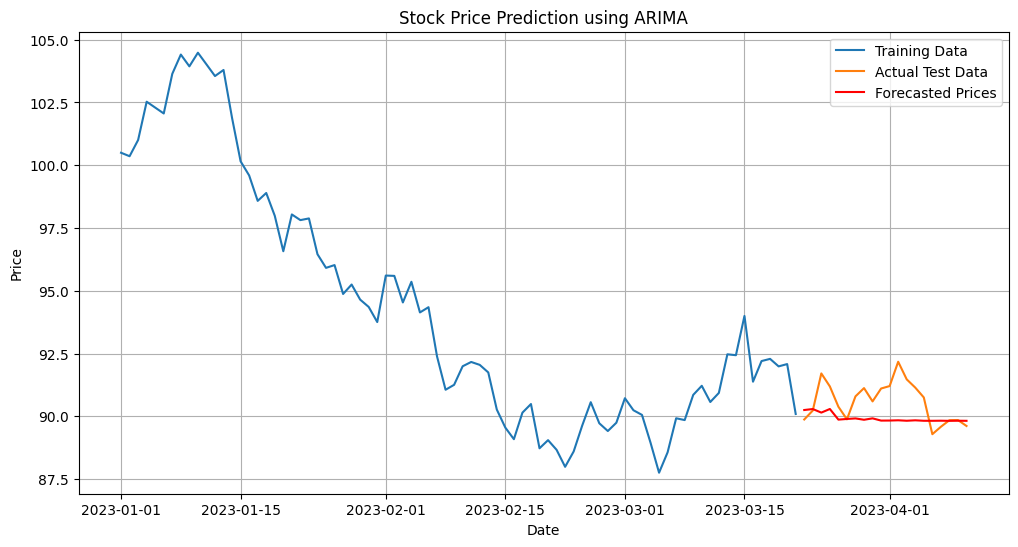

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# 1. Generate synthetic stock price data
np.random.seed(42)
dates = pd.date_range(start='2023-01-01', periods=100, freq='D')
prices = np.cumsum(np.random.normal(0, 1, 100)) + 100
stock_data = pd.DataFrame({'Date': dates, 'Price': prices})
stock_data.set_index('Date', inplace=True)

print("Generated Stock Data Head:")
print(stock_data.head())

# 2. Split data into training and testing (optional, but good practice)
train_size = int(len(stock_data) * 0.8)
train_data, test_data = stock_data['Price'][0:train_size], stock_data['Price'][train_size:]

# 3. Define and train an ARIMA model
# (p,d,q) are order parameters. (1,1,1) is a common starting point.
model = ARIMA(train_data, order=(5,1,0)) # Example order, might need tuning
model_fit = model.fit()

print("\nARIMA Model Summary:")
print(model_fit.summary())

# 4. Make predictions
# Forecast for the next 20 days (or length of test_data)
forecast_steps = len(test_data) # Or a fixed number like 20
forecast = model_fit.forecast(steps=forecast_steps)

print(f"\nForecasted Prices for the next {forecast_steps} periods:")
print(forecast)

# 5. Visualize the results (optional)
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data, label='Training Data')
plt.plot(test_data.index, test_data, label='Actual Test Data')
plt.plot(forecast.index, forecast, label='Forecasted Prices', color='red')
plt.title('Stock Price Prediction using ARIMA')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()